## Case Study: Survival Analysis by Passenger Class and Gender

    Business Problem
    A maritime safety board wants to understand which passenger groups had the highest survival rates during the Titanic disaster.
    The insights will help evaluate evacuation priorities and identify vulnerable groups.

    Business Questions
    1.Which passenger class had the highest survival rate?
    2.Did gender influence survival within each passenger class?

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

In [12]:
df=sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### Survival Count by Passenger Class?

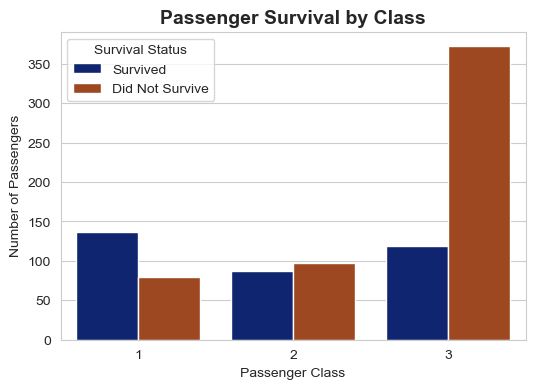

In [10]:
plt.figure(figsize=(6,4))
df["survival_status"] = df["survived"].map({
    0: "Did Not Survive",
    1: "Survived"
})
sns.countplot(
    data=df,
    x="pclass",
    hue="survival_status",
    palette="dark"
)

plt.title("Passenger Survival by Class", fontsize=14, fontweight="bold")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survival Status")

plt.show()

### Survival by Gender and Passenger Class?

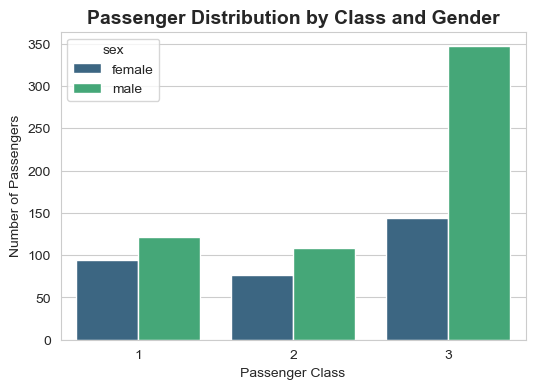

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="pclass",
    hue="sex",
    palette="viridis"
)

plt.title("Passenger Distribution by Class and Gender", fontsize=14, fontweight="bold")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

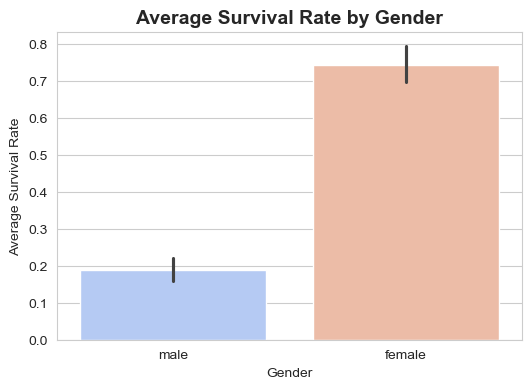

In [17]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=df,
    x="sex",
    y="survived",
    hue='sex',
    palette="coolwarm"
)

plt.title("Average Survival Rate by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Average Survival Rate")

plt.show()

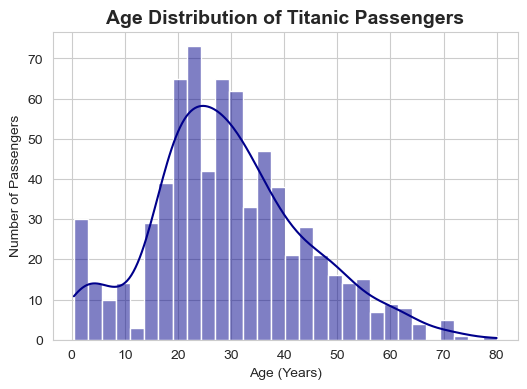

In [19]:
plt.figure(figsize=(6,4))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True,
    color="darkblue"
)

plt.title("Age Distribution of Titanic Passengers", fontsize=14, fontweight="bold")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Passengers")

plt.show()

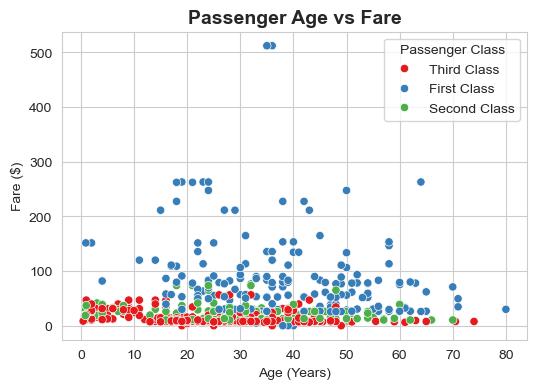

In [21]:
plt.figure(figsize=(6,4))

df["Passenger Class"] = df["pclass"].map({
    1: "First Class",
    2: "Second Class",
    3: "Third Class"
})

sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="Passenger Class",
    palette="Set1"
)

plt.title("Passenger Age vs Fare", fontsize=14, fontweight="bold")
plt.xlabel("Age (Years)")
plt.ylabel("Fare ($)")

plt.show()

### How does fare differ across passenges classes?

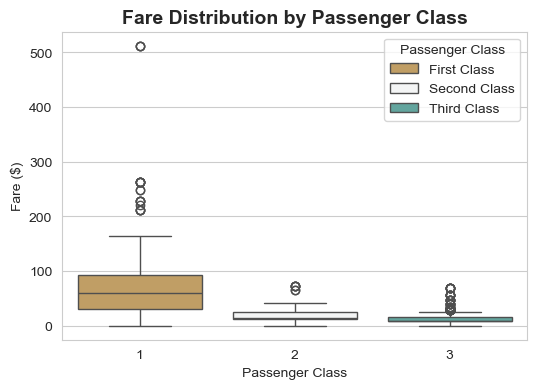

In [27]:
plt.figure(figsize=(6,4))

df["Passenger Class"] = df["pclass"].map({
    1: "First Class",
    2: "Second Class",
    3: "Third Class"
})
sns.boxplot(
    data=df,
    x="pclass",
    y="fare",
    hue='Passenger Class',
    palette="BrBG"
)

plt.title("Fare Distribution by Passenger Class", fontsize=14, fontweight="bold")
plt.xlabel("Passenger Class")
plt.ylabel("Fare ($)")

plt.show()

### How does the average fare change across passenger classes?

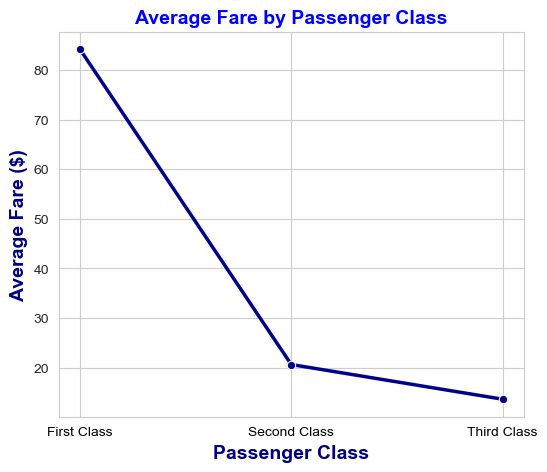

In [38]:
avg_fare = df.groupby("pclass", as_index=False)["fare"].mean()

plt.figure(figsize=(6,5))



sns.lineplot(
    data=avg_fare,
    x="pclass",
    y="fare",

    marker="o",
    linewidth=2.5,
    color="darkblue"
)

plt.title("Average Fare by Passenger Class", fontsize=14, fontweight="bold",color='blue')
plt.xlabel("Passenger Class",fontsize=14, fontweight="bold",color='navy')
plt.ylabel("Average Fare ($)",fontsize=14, fontweight="bold",color='navy')


plt.xticks(
    ticks=[1, 2, 3],
    labels=["First Class", "Second Class", "Third Class"],color='black'
)
#plt.grid(True)

plt.show()

# Final Business Conclusion
    -Most passengers were young adults (20–40 years).
    -Passenger class strongly influenced ticket price.
    -First-class passengers paid the highest fares and showed greater fare variation.
    -Several premium ticket purchases appear as outliers rather than data errors.
    -Age has little influence on ticket fare, indicating that pricing was driven mainly by travel class rather than passenger age.